KKBox Churn - Exploratory Data Analysis

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
train = pd.read_csv("data/processed/train_sample.csv") 
transactions = pd.read_csv("data/processed/transactions_sample.csv") 
members = pd.read_csv("data/processed/members_sample.csv") 
print("train:", train.shape) 
print("transactions:", transactions.shape) 
print("members:", members.shape)

train: (80000, 2)
transactions: (1187281, 9)
members: (72495, 6)


In [6]:
print("Missing values in train:") 
print(train.isnull().sum()) 
print("\nMissing values in members:") 
print(members.isnull().sum()) 
print("\nMissing values in transactions:") 
print(transactions.isnull().sum())

Missing values in train:
msno        0
is_churn    0
dtype: int64

Missing values in members:
msno                          0
city                          0
bd                            0
gender                    34025
registered_via                0
registration_init_time        0
dtype: int64

Missing values in transactions:
msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64


In [8]:
churn_rate = train['is_churn'].mean() 
print(f"Churn rate in sample: {churn_rate:.2%}") 
train['is_churn'].value_counts()

Churn rate in sample: 50.00%


is_churn
0    40000
1    40000
Name: count, dtype: int64

In [9]:
members['bd'].describe()

count    72495.000000
mean        15.523084
std         17.773843
min        -49.000000
25%          0.000000
50%         18.000000
75%         28.000000
max       1037.000000
Name: bd, dtype: float64

In [10]:
invalid_age = members[(members['bd'] <= 0) | (members['bd'] > 100)] 
print(f"Invalid ages: {len(invalid_age):,} out of {len(members):,} " f"({100*len(invalid_age)/len(members):.1f}%)") 

Invalid ages: 33,686 out of 72,495 (46.5%)


In [11]:
members['bd_clean'] = members['bd'].where((members['bd'] > 0) & (members['bd'] <= 100)) 
print(members['bd_clean'].describe())

count    38809.000000
mean        28.752532
std          8.970650
min          1.000000
25%         22.000000
50%         27.000000
75%         33.000000
max        100.000000
Name: bd_clean, dtype: float64


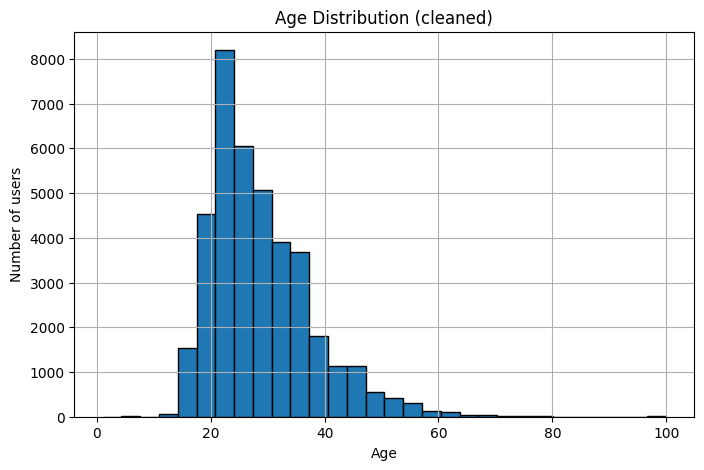

In [13]:
plt.figure(figsize=(8, 5)) 
members['bd_clean'].dropna().hist(bins=30, edgecolor='black') 
plt.xlabel('Age') 
plt.ylabel('Number of users') 
plt.title('Age Distribution (cleaned)') 
plt.show()

In [15]:
churn_by_gender = train.merge(members[['msno', 'gender']], on='msno', how='left') 
churn_by_gender.groupby('gender')['is_churn'].agg(['mean', 'count'])

,mean,count
gender,,
female,0.602999,18204
male,0.600957,20266


In [20]:
churn_by_gender['has_gender'] = churn_by_gender['gender'].notna() 
churn_by_gender.groupby('has_gender')['is_churn'].agg(['mean', 'count'])

,mean,count
has_gender,,
False,0.405586,41530
True,0.601924,38470


In [23]:
latest_txn = transactions.sort_values('transaction_date').groupby('msno').last().reset_index() 
churn_by_renew = train.merge(latest_txn[['msno', 'is_auto_renew', 'payment_method_id']], on='msno', how='left') 
churn_by_renew.groupby('is_auto_renew')['is_churn'].agg(['mean', 'count'])

,mean,count
is_auto_renew,,
0,0.881047,25262
1,0.324144,54738


In [24]:
churn_by_renew.groupby('payment_method_id')['is_churn'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)

,mean,count
payment_method_id,,
41,0.291191,33442
38,0.849429,11297
36,0.619125,7383
40,0.410290,5306
32,0.997048,4742
39,0.396210,4591
29,0.696477,2214
37,0.234742,2130
30,0.607809,1716


Nearly half the age values (~46%) were invalid and needed cleaning before they could be used.
Customers with a complete profile — specifically, those with gender listed — churn about 20 points less than those without one.
Auto-renewal status is a strong predictor: churn is just 32% for auto-renew users, compared to 88% for those who aren't.
Payment method matters a lot more than you'd expect, with churn ranging from as low as 17.6% to as high as 99.7% depending on which one's used.